# Deep Exploration: RND vs Bootstrapped DQN on DeepSea

In hard-exploration tasks, reward is sparse and only a long, *specific* sequence
of actions ever reaches it. Naive ε-greedy dithering finds that sequence with
probability that shrinks exponentially in the horizon. **Deep exploration** means
committing to a coherent, multi-step plan to reach the unknown frontier. This
project compares two classic deep-exploration agents on the **DeepSea**
benchmark, on a normal board and on a *noisy-TV* variant.

### Random Network Distillation (RND) — *novelty by prediction error*
- A **frozen random target** network `f̄(s)` maps states to an embedding and is never trained.
- A **predictor** `f(s)` is trained to match `f̄` on visited states; its error is large on novel states.
- The per-state **intrinsic bonus** — how far the predictor's embedding sits from the target's — is added to the reward, pulling the agent toward unfamiliar states.

### Bootstrapped DQN with randomized priors — *novelty by disagreement*
- An **ensemble of K heads**, each a trainable Q-net plus a *frozen randomized prior*, expresses value uncertainty.
- **Bootstrap masks** give each head a different sample of the data, keeping the heads diverse.
- **Posterior sampling**: one head is drawn per episode and followed greedily — approximate Thompson sampling, exploration *without* ε-greedy noise.

### Papers
- RND — Burda et al. 2018: https://arxiv.org/abs/1810.12894
- Bootstrapped DQN — Osband et al. 2016: https://arxiv.org/abs/1602.04621
- Randomized prior functions — Osband et al. 2018: https://arxiv.org/abs/1806.03335
- DeepSea / bsuite — Osband et al. 2019: https://arxiv.org/abs/1908.03568

### What you will do
1. Implement one **exploration metric** (coverage + entropy).
2. Build the networks/ensemble and implement the learning cores of **RND** and **Bootstrapped DQN**.
3. Quickly test each implementation on a small DeepSea.
4. Run the full **normal vs noisy** comparison and inspect the figures.
5. Answer the analysis questions.

You edit **three short files** — `hw/student_metric.py`, `hw/student_rnd.py`,
and `hw/student_bootstrap.py` — one per section (B, C, D), each through its
own `%%writefile` cell. Everything else is provided.

### Grading
The project is worth **100 points**: **70** for the implementations and **30** for
the analysis questions.

- **Implementations (70)** — Section B *(8)*, Section C *(28)*, Section D *(34)*.
- **Analysis questions (30)** — Section G.

Each function and each question shows its exact share next to it.

### Submitting
Set **`STUDENT_NUMBER`** at the top of the Setup section — it is written into
`exploration_artifacts.zip`. Then run the notebook top to bottom. The final cell writes
**`exploration_artifacts.zip`** (< 10 MB: your implementation fingerprints + the run
records). Submit that file together with this notebook.


## Setup


In [2]:
# ============================================================
#  STUDENT NUMBER -- fill this in before running the notebook.
#  It is stamped into every training run and into submission.zip,
#  so we can confirm you ran the notebook yourself.
# ============================================================
STUDENT_NUMBER = "401105815"

assert STUDENT_NUMBER.strip(), "Set STUDENT_NUMBER (top of the Setup cell) before running."

import importlib
import sys

%matplotlib inline

# Make the provided modules in hw/ importable.
sys.path.insert(0, "modules")

import numpy as np
import torch

# The three files you edit, one per section. Re-import each after its
# %%writefile cell with importlib.reload (each section shows how).
import student_metric
import student_rnd
import student_bootstrap

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)


def set_seed(seed: int) -> None:
    # Seed Python, NumPy and torch for reproducible cells.
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

torch 2.11.0+cu128 | device: cuda


## Section A — DeepSea and the noisy TV

**DeepSea** is an `N×N` grid. The agent starts at the top-left and is **forced to
descend exactly one row per step**, so every episode is exactly `N` steps. In each
column a fixed (per-column randomized) mapping decides which of the two raw
actions means *go right*. Going right costs a tiny penalty; the only large reward
(**+1**) sits in the **bottom-right** cell. Reaching the treasure requires
choosing *right* on every single step — an ε-greedy explorer stumbles onto it
with probability `2⁻ᴺ`. Only the **lower triangle** (column ≤ row) is reachable.
The *always-right* policy is the reference (solved) return, `1 − 0.01 = 0.99`.

**Noisy-TV variant.** Setting `ds_noise_dim = d > 0` appends `d` extra observation
features that carry **fresh uniform random noise while — and only while — the
agent sits in a designated column** (by default column 0, the left wall, the
*opposite* side from the treasure); elsewhere those features are zero. This noise
is **action-independent and reward-irrelevant**: it changes nothing about the
dynamics or the optimal policy. It is a localized "noisy television".

The two boards below are identical except for those left-wall noise features.


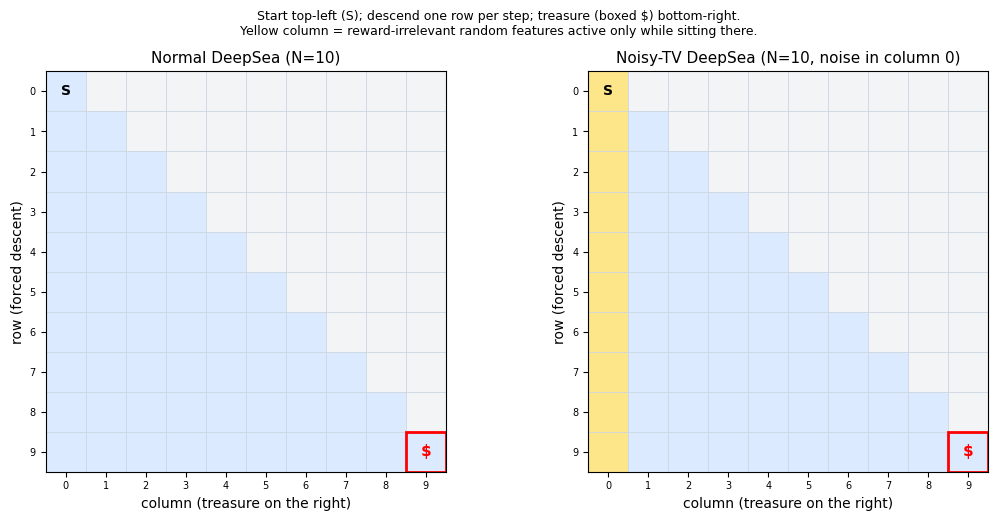

In [3]:
import hw_plots

SIZE = 10  # DeepSea side length N used throughout
hw_plots.show_demo_boards(SIZE)

## Section B — Exploration metric

We measure exploration over the **reachable** cells with two quantities,
snapshotted periodically during training:

- **Coverage** — the fraction of reachable cells visited at least once (breadth).
- **Visitation entropy (bits)** — the Shannon entropy of the visit distribution
  over the reachable cells. High coverage *and* high entropy means broad, even
  exploration; low entropy means the agent keeps revisiting a few cells.

Implement **`coverage_entropy`** **(8 pts)** in the `%%writefile hw/student_metric.py`
cell below, then run that cell **and** the check cell under it. It is the only
function for this section.


In [4]:
%%writefile modules/student_metric.py
"""Section B of the homework: the exploration metric."""

from __future__ import annotations

import numpy as np


def coverage_entropy(
    visit_counts: "np.ndarray", reachable_mask: "np.ndarray"
) -> tuple[float, float]:
    """Return reachable-state coverage and visitation entropy in bits."""
    counts = np.asarray(visit_counts)
    mask = np.asarray(reachable_mask, dtype=bool)
    if counts.shape != mask.shape:
        raise ValueError("visit_counts and reachable_mask must have the same shape")
    if np.any(counts < 0):
        raise ValueError("visit_counts must be non-negative")

    reachable = counts[mask].astype(np.float64, copy=False)
    num_reachable = reachable.size
    if num_reachable == 0:
        return 0.0, 0.0

    coverage = float(np.count_nonzero(reachable) / num_reachable)
    total = float(reachable.sum())
    if total <= 0.0:
        return coverage, 0.0

    probs = reachable[reachable > 0.0] / total
    entropy_bits = float(-np.sum(probs * np.log2(probs)))
    return coverage, entropy_bits


Overwriting hw/student_metric.py


In [5]:
# Reload so the modules that call student_metric pick up your latest edits.
importlib.reload(student_metric)

# Unit-check coverage_entropy on a small hand-built grid.
from metrics import reachable_mask

_counts = np.array([
    [4, 0, 0, 0],
    [2, 2, 0, 0],
    [0, 1, 1, 0],
    [0, 0, 0, 0],
], dtype=np.int64)
_reach = reachable_mask(4)              # lower triangle: 1+2+3+4 = 10 cells
cov, ent = student_metric.coverage_entropy(_counts, _reach)
print(f"coverage={cov:.4f}  entropy={ent:.4f} bits")

# 5 of 10 reachable cells visited.
assert abs(cov - 0.5) < 1e-9, cov
# Entropy of [4,2,2,1,1]/10 over the visited cells.
_p = np.array([4, 2, 2, 1, 1]) / 10
_expected = float(-(_p * np.log2(_p)).sum())
assert abs(ent - _expected) < 1e-9, (ent, _expected)
print("coverage_entropy OK")

coverage=0.5000  entropy=2.1219 bits
coverage_entropy OK


## Section C — Random Network Distillation

RND scores a state's novelty by how badly a trained **predictor** reproduces the
output of a frozen random **target** on it; that error is added to the reward as an
exploration bonus and fades as a state becomes familiar (see the intro and Burda et
al. 2018).

**Action selection is provided** — RND acts with the same standard ε-greedy policy
as plain DQN — so you implement only its learning core, in the
`%%writefile hw/student_rnd.py` cell below:

- **`build_rnd_networks`** **(8 pts)** — you build the two embedding networks
  yourself: a frozen random **target** and a trainable **predictor**, each an
  `nn.Module` mapping an observation to an `output_dim` embedding. The target must
  never train; the architectures are yours.
- **`rnd_intrinsic_bonus`** **(10 pts)** — the per-state novelty bonus (detached,
  normalised via `agent.intrinsic_rms`) and the predictor's regression loss
  (differentiable).
- **`rnd_td_target`** **(6 pts)** — the Double-DQN target on the *shaped* reward.
- **`rnd_q_loss`** **(4 pts)** — the critic loss: `Q(s, a)` for the actions taken
  vs. your `rnd_td_target`.

Run that cell, then the reload + quick-test cell below it (it trains RND on a small
DeepSea and checks it reaches the treasure; `recorder=None`, so the metric is not
needed here).


In [6]:
%%writefile modules/student_rnd.py
"""Section C of the homework: Random Network Distillation (RND)."""

from __future__ import annotations

from typing import TYPE_CHECKING

import torch
import torch.nn as nn
import torch.nn.functional as F

if TYPE_CHECKING:
    from rnd_dqn import RNDDoubleDQN


def _mlp(in_size: int, out_size: int, hidden_sizes: tuple[int, ...]) -> nn.Sequential:
    layers: list[nn.Module] = []
    width = in_size
    for hidden in hidden_sizes:
        layers.extend((nn.Linear(width, hidden), nn.ReLU()))
        width = hidden
    layers.append(nn.Linear(width, out_size))
    return nn.Sequential(*layers)


def build_rnd_networks(
    obs_size: int, output_dim: int, hidden_sizes: tuple[int, ...]
) -> tuple[nn.Module, nn.Module]:
    """Build a frozen random target and a trainable predictor MLP."""
    target = _mlp(obs_size, output_dim, hidden_sizes)
    predictor = _mlp(obs_size, output_dim, hidden_sizes)
    for parameter in target.parameters():
        parameter.requires_grad_(False)
    target.eval()
    return target, predictor


def rnd_intrinsic_bonus(
    agent: "RNDDoubleDQN", next_obs: "torch.Tensor"
) -> tuple["torch.Tensor", "torch.Tensor"]:
    """Compute normalized per-state RND error and predictor MSE loss."""
    with torch.no_grad():
        target_embedding = agent.rnd_target(next_obs)
    predictor_embedding = agent.rnd_predictor(next_obs)

    # Mean squared embedding error gives one raw novelty value per transition.
    raw_error = (predictor_embedding - target_embedding).pow(2).mean(dim=1)
    predictor_loss = raw_error.mean()

    raw_detached = raw_error.detach()
    agent.intrinsic_rms.update(raw_detached.cpu().numpy())
    scale = max(float(agent.intrinsic_rms.std), 1e-8)
    intrinsic = raw_detached / scale
    return intrinsic, predictor_loss


def rnd_td_target(
    agent: "RNDDoubleDQN",
    shaped_reward: "torch.Tensor",
    next_obs: "torch.Tensor",
    done: "torch.Tensor",
) -> "torch.Tensor":
    """Build the Double-DQN target on shaped rewards."""
    with torch.no_grad():
        next_action = agent.online(next_obs).argmax(dim=1, keepdim=True)
        next_q = agent.target(next_obs).gather(1, next_action).squeeze(1)
        return shaped_reward + agent.cfg.gamma * (1.0 - done) * next_q


def rnd_q_loss(
    agent: "RNDDoubleDQN",
    obs: "torch.Tensor",
    action: "torch.Tensor",
    shaped_reward: "torch.Tensor",
    next_obs: "torch.Tensor",
    done: "torch.Tensor",
) -> "torch.Tensor":
    """Return Huber loss between Q(s,a) and the shaped Double-DQN target."""
    q_taken = agent.online(obs).gather(1, action.long().unsqueeze(1)).squeeze(1)
    target = rnd_td_target(agent, shaped_reward, next_obs, done)
    return F.smooth_l1_loss(q_taken, target)


Overwriting hw/student_rnd.py


In [7]:
import rnd_dqn
importlib.reload(student_rnd)  # ensure your latest student_rnd is in use

set_seed(0)
qt_steps = 15_000
cfg = rnd_dqn.Config(
    size=6, total_steps=qt_steps, seed=0, device=DEVICE,
    run_name="quicktest_rnd", checkpoint_every=qt_steps,
    epsilon_decay_steps=int(0.8 * qt_steps), intrinsic_coef=1.0,
)
agent = rnd_dqn.run_training(cfg, recorder=None)

# Greedy rollout: with a correct RND the agent should now run right to the treasure.
env = agent.env.clone()
obs, _ = env.reset(seed=0)
ret = 0.0
for _ in range(env.size):
    a = agent.select_action(obs, epsilon=0.0)
    step = env.step(a)
    obs, ret = step.observation, ret + step.reward
print(f"RND greedy return = {ret:.3f}  (reference {env.reference_return:.3f})")
assert ret >= 0.8 * env.reference_return, "RND did not solve N=6 — check your implementation"
print("RND quick test OK")

DeepSea(N=6) reference_return=0.9900 intrinsic_coef=1.0 device=cuda
step    5000 | episodes   833 | eps 0.604 | int_std  0.0005 | mean100 return  0.0955 | reference 0.9900 | time 0:00:19
step   10000 | episodes  1666 | eps 0.208 | int_std  0.0003 | mean100 return  0.5332 | reference 0.9900 | time 0:00:43
step   15000 | episodes  2500 | eps 0.050 | int_std  0.0003 | mean100 return  0.9219 | reference 0.9900 | time 0:01:08
  checkpoint -> checkpoints/quicktest_rnd/step_00015000.pt
RND greedy return = 0.992  (reference 0.990)
RND quick test OK


## Section D — Bootstrapped DQN

Bootstrapped DQN explores by **disagreement**: an ensemble of independently
initialised value heads (each plus a frozen randomized prior) disagrees about
states the data has not pinned down. One head is sampled per episode and followed
greedily — approximate Thompson sampling, with no ε-greedy noise (see the intro and
Osband et al. 2016/2018).

Implement the following in the `%%writefile hw/student_bootstrap.py` cell below:

- **`build_bootstrap_ensemble`** **(10 pts)** — you build the `num_heads` ensemble
  heads yourself. Each head is an `nn.Module` pairing a trainable network with a
  *frozen randomized prior*, output `Q_k(s) = trainable_k(s) + prior_scale · prior_k(s)`.
  Independent random init is what makes the heads disagree.
- **`boot_sample_head`** **(3 pts)** — posterior sampling: pick the single head to
  follow for the next episode (the only exploration mechanism).
- **`boot_select_action`** **(4 pts)** — greedy action under that one head (the
  behaviour policy during an episode).
- **`boot_eval_action`** **(5 pts)** — the *evaluation* policy: greedy under the
  ensemble-**mean** Q.
- **`boot_head_target`** **(6 pts)** — the per-head Double-DQN target.
- **`boot_head_loss`** **(6 pts)** — the masked per-head loss: `Q(s, a)` vs. your
  `boot_head_target`, averaged over the head's bootstrap-masked transitions.

Run that cell, then the reload + quick-test cell below it.


In [8]:
%%writefile modules/student_bootstrap.py
"""Section D of the homework: Bootstrapped DQN with randomized priors."""

from __future__ import annotations

from typing import TYPE_CHECKING

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

if TYPE_CHECKING:
    from bootstrap_dqn import BootstrappedDQN


def _mlp(in_size: int, out_size: int, hidden_sizes: tuple[int, ...]) -> nn.Sequential:
    layers: list[nn.Module] = []
    width = in_size
    for hidden in hidden_sizes:
        layers.extend((nn.Linear(width, hidden), nn.ReLU()))
        width = hidden
    layers.append(nn.Linear(width, out_size))
    return nn.Sequential(*layers)


class RandomizedPriorHead(nn.Module):
    """A trainable Q-network plus an independent frozen randomized prior."""

    def __init__(
        self,
        obs_size: int,
        num_actions: int,
        prior_scale: float,
        hidden_sizes: tuple[int, ...],
    ) -> None:
        super().__init__()
        self.trainable = _mlp(obs_size, num_actions, hidden_sizes)
        self.prior = _mlp(obs_size, num_actions, hidden_sizes)
        self.prior_scale = float(prior_scale)
        for parameter in self.prior.parameters():
            parameter.requires_grad_(False)
        self.prior.eval()

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        # Detaching is redundant because prior parameters are frozen, but makes the
        # fixed-function intent explicit while preserving gradients through obs.
        return self.trainable(obs) + self.prior_scale * self.prior(obs)


def build_bootstrap_ensemble(
    obs_size: int,
    num_actions: int,
    num_heads: int,
    prior_scale: float,
    hidden_sizes: tuple[int, ...],
) -> "nn.ModuleList":
    """Build K independent randomized-prior Q heads."""
    return nn.ModuleList(
        [
            RandomizedPriorHead(
                obs_size, num_actions, prior_scale, hidden_sizes
            )
            for _ in range(num_heads)
        ]
    )


def boot_sample_head(agent: "BootstrappedDQN", rng: "np.random.Generator") -> int:
    """Uniformly sample one acting head for an episode."""
    return int(rng.integers(agent.cfg.num_heads))


def boot_select_action(agent: "BootstrappedDQN", obs: "np.ndarray", head: int) -> int:
    """Choose the greedy action under the selected head."""
    obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=agent.device).unsqueeze(0)
    with torch.no_grad():
        q_values = agent.ensemble[head](obs_tensor)
    return int(q_values.argmax(dim=1).item())


def boot_eval_action(agent: "BootstrappedDQN", obs: "np.ndarray") -> int:
    """Choose greedily under ensemble-mean Q-values."""
    obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=agent.device).unsqueeze(0)
    with torch.no_grad():
        q_values = torch.stack([head(obs_tensor) for head in agent.ensemble], dim=0)
        mean_q = q_values.mean(dim=0)
    return int(mean_q.argmax(dim=1).item())


def boot_head_target(
    agent: "BootstrappedDQN",
    online_k: "nn.Module",
    target_k: "nn.Module",
    reward: "torch.Tensor",
    next_obs: "torch.Tensor",
    done: "torch.Tensor",
) -> "torch.Tensor":
    """Build one head's Double-DQN target."""
    with torch.no_grad():
        next_action = online_k(next_obs).argmax(dim=1, keepdim=True)
        next_q = target_k(next_obs).gather(1, next_action).squeeze(1)
        return reward + agent.cfg.gamma * (1.0 - done) * next_q


def boot_head_loss(
    agent: "BootstrappedDQN",
    online_k: "nn.Module",
    target_k: "nn.Module",
    obs: "torch.Tensor",
    action: "torch.Tensor",
    reward: "torch.Tensor",
    next_obs: "torch.Tensor",
    done: "torch.Tensor",
    mask: "torch.Tensor",
) -> "torch.Tensor":
    """Return mean masked Huber loss for one ensemble head."""
    q_taken = online_k(obs).gather(1, action.long().unsqueeze(1)).squeeze(1)
    target = boot_head_target(agent, online_k, target_k, reward, next_obs, done)
    per_item = F.smooth_l1_loss(q_taken, target, reduction="none")
    return (per_item * mask).sum() / mask.sum().clamp_min(1.0)


Overwriting hw/student_bootstrap.py


In [9]:
import bootstrap_dqn
importlib.reload(student_bootstrap)

set_seed(0)
cfg = bootstrap_dqn.Config(
    size=6, total_steps=8_000, seed=0, device=DEVICE,
    run_name="quicktest_boot", checkpoint_every=8_000,
    num_heads=5, prior_scale=3.0, mask_prob=0.5,
)
agent = bootstrap_dqn.run_training(cfg, recorder=None)

env = agent.env.clone()
obs, _ = env.reset(seed=0)
ret = 0.0
for _ in range(env.size):
    a = agent.select_action(obs, head=0)
    step = env.step(a)
    obs, ret = step.observation, ret + step.reward
print(f"Bootstrap head-0 greedy return = {ret:.3f}  (reference {env.reference_return:.3f})")
assert ret >= 0.8 * env.reference_return, "Bootstrap did not solve N=6 — check your implementation"
print("Bootstrap quick test OK")

DeepSea(N=6) reference_return=0.9900 heads=5 prior_scale=3.0 device=cuda
step    5000 | episodes   833 | heads  5 | mean100 return  0.9916 | reference 0.9900 | time 0:00:56
  checkpoint -> checkpoints/quicktest_boot/step_00008000.pt
Bootstrap head-0 greedy return = 0.992  (reference 0.990)
Bootstrap quick test OK


## Section E — Full comparison: normal vs noisy DeepSea

This trains **both agents** across **multiple seeds** on the normal board and on
the noisy-TV board, threading your metric through every run, then runs the full
analysis. The sweep is **resumable** — re-running skips finished runs — and trains
runs concurrently (`WORKERS`).

The config cell separates **experiment settings** from **algorithm
hyperparameters**:

- **Experiment settings** — `SIZE`, `SEEDS`, `TOTAL_STEPS`, `NOISE_DIM`,
  `NOISE_COLUMNS`. **Leave these at their given values in the run you submit**, so
  every submission is compared on exactly the same task.
- **Algorithm hyperparameters** — `NUM_HEADS`, `PRIOR_SCALE`, `MASK_PROB`,
  `INTRINSIC_COEF`, `RND_OUTPUT_DIM`. These are yours to **tune**.

While exploring you may lower `TOTAL_STEPS` / `SEEDS` for a faster, noisier pass —
just restore the given experiment settings for your final submitted run.


In [10]:
import hw_experiment

# --- experiment configuration ---
# Experiment settings: KEEP THESE AT THEIR GIVEN VALUES IN THE RUN YOU SUBMIT.
# (You may change them while exploring, but your submitted sweep must use these.)
SIZE          = 15
SEEDS         = (0, 1, 2,42)
TOTAL_STEPS   = 20_000
NOISE_DIM     = 15
NOISE_COLUMNS = (0,)

# Algorithm hyperparameters: you MAY tune these.
NUM_HEADS      = 5
PRIOR_SCALE    = 3.0
MASK_PROB      = 0.5
INTRINSIC_COEF = 1.0
RND_OUTPUT_DIM = 64

# Runtime only (no effect on results): set to your hardware.
WORKERS    = 4
EXP_DEVICE = DEVICE

hw_experiment.run_full_comparison(
    size=SIZE, seeds=SEEDS, total_steps=TOTAL_STEPS, device=EXP_DEVICE,
    workers=WORKERS, num_heads=NUM_HEADS, prior_scale=PRIOR_SCALE,
    mask_prob=MASK_PROB, intrinsic_coef=INTRINSIC_COEF,
    rnd_output_dim=RND_OUTPUT_DIM, noise_dim=NOISE_DIM, noise_columns=NOISE_COLUMNS,
)


===== NORMAL DeepSea (N=15) =====
experiment[deepsea]: 3 agents x 1 sizes x 4 seeds = 12 runs, 20000 steps each, workers=4
    ... still training: 0/12 runs done (30s elapsed)
    ... still training: 0/12 runs done (60s elapsed)
    ... still training: 0/12 runs done (90s elapsed)
    ... still training: 0/12 runs done (120s elapsed)
    ... still training: 0/12 runs done (150s elapsed)
    ... still training: 0/12 runs done (180s elapsed)
[1/12] double_dqn n=15 seed=1: saved results/normal/runs/double_dqn/n15_seed1.npz
[2/12] double_dqn n=15 seed=42: saved results/normal/runs/double_dqn/n15_seed42.npz
[3/12] double_dqn n=15 seed=2: saved results/normal/runs/double_dqn/n15_seed2.npz
[4/12] double_dqn n=15 seed=0: saved results/normal/runs/double_dqn/n15_seed0.npz
    ... still training: 4/12 runs done (236s elapsed)
    ... still training: 4/12 runs done (266s elapsed)
    ... still training: 4/12 runs done (296s elapsed)
    ... still training: 4/12 runs done (326s elapsed)
    ... s

## Section F — Results and plots

The figures below come from the two sweeps. Compare the agents **within** each
board, and compare each agent **across** the two boards.


################  NORMAL DeepSea  ################
--- learning + coverage: results/normal ---


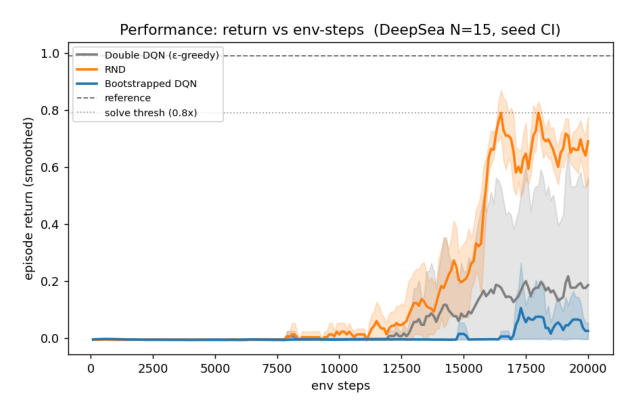

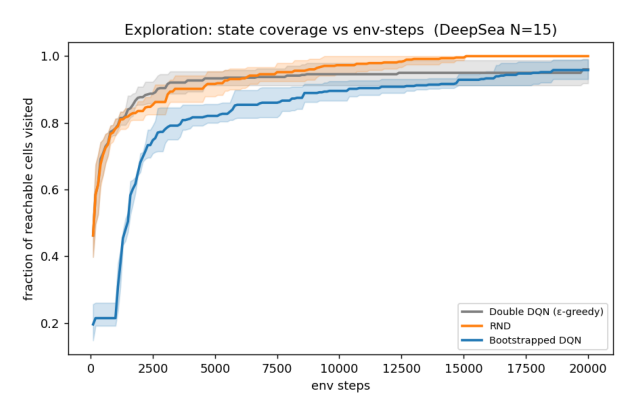

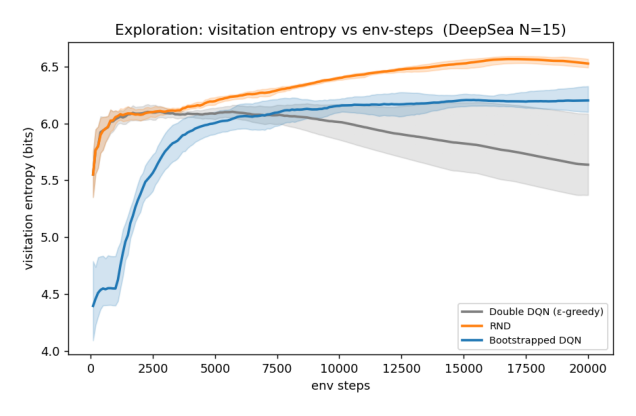

--- visitation heatmaps: results/normal ---


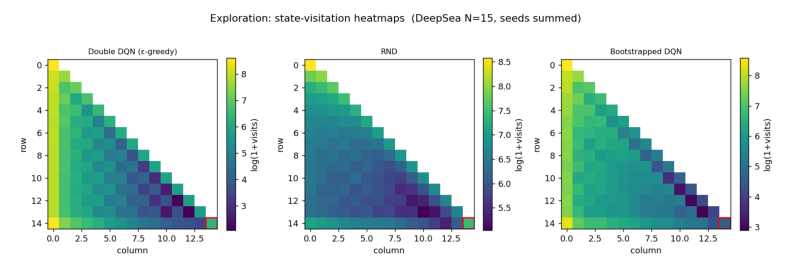

--- statistical rigor: results/normal ---


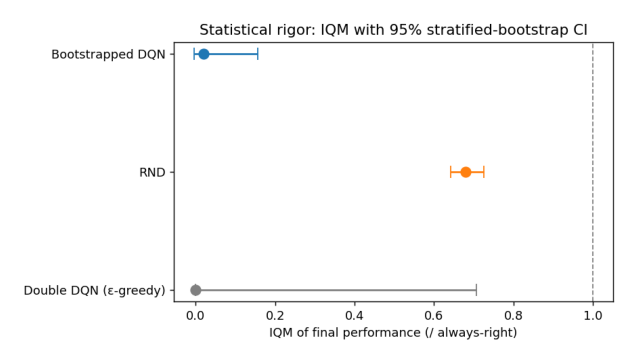

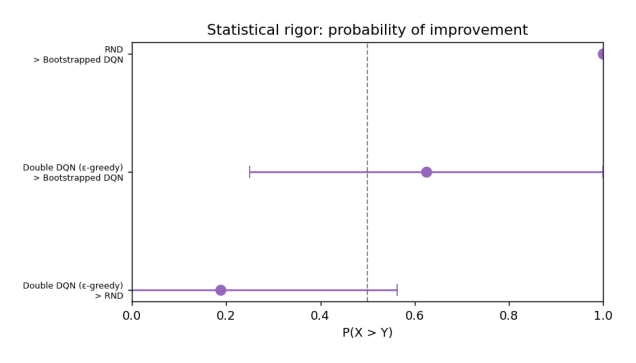

In [11]:
import hw_plots
importlib.reload(hw_plots)

print("################  NORMAL DeepSea  ################")
hw_plots.show_learning_and_coverage("results/normal")
hw_plots.show_heatmaps("results/normal")
hw_plots.show_rigor("results/normal")

################  NOISY-TV DeepSea  ################
--- learning + coverage: results/noisy ---


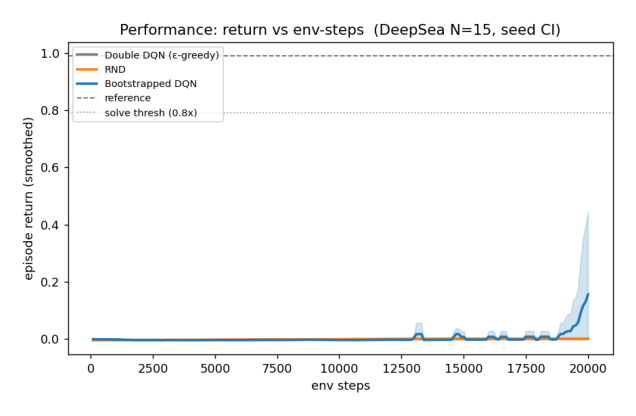

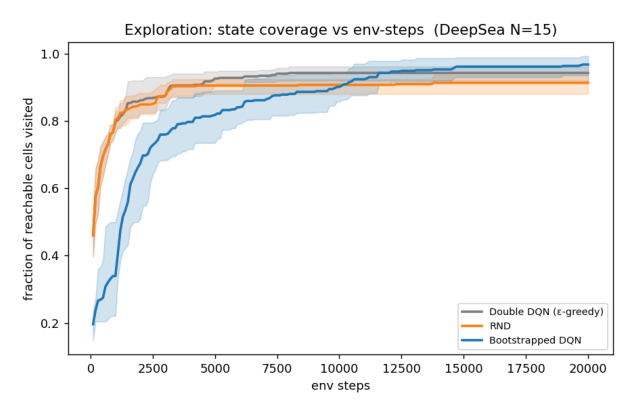

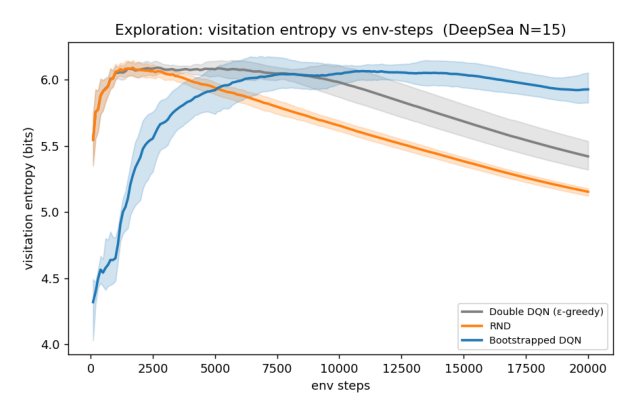

--- visitation heatmaps: results/noisy ---


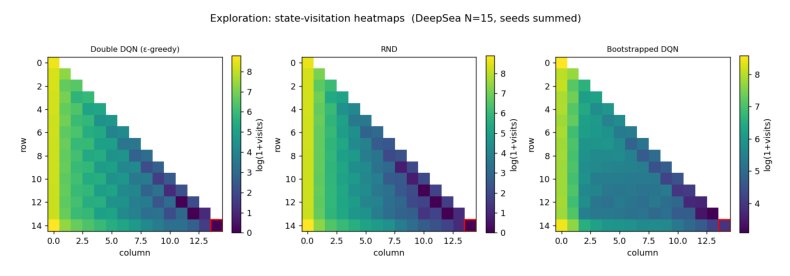

--- statistical rigor: results/noisy ---


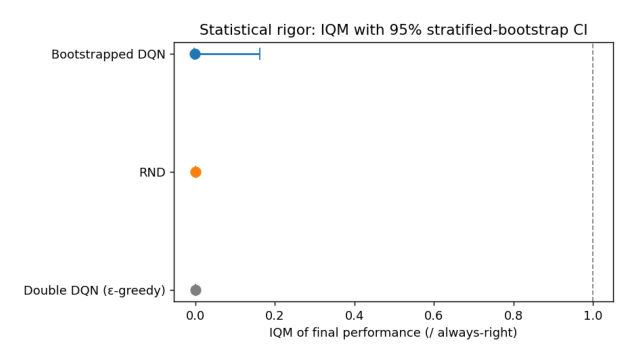

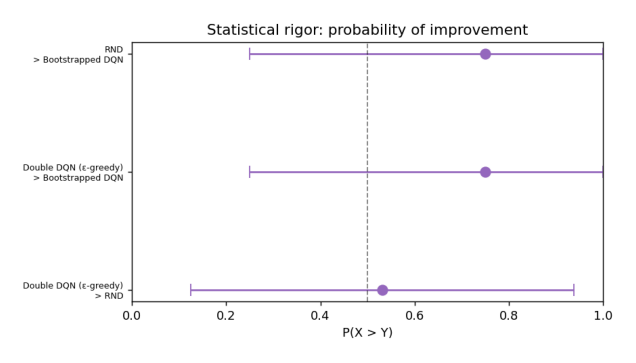

In [12]:
print("################  NOISY-TV DeepSea  ################")
hw_plots.show_learning_and_coverage("results/noisy")
hw_plots.show_heatmaps("results/noisy")
hw_plots.show_rigor("results/noisy")

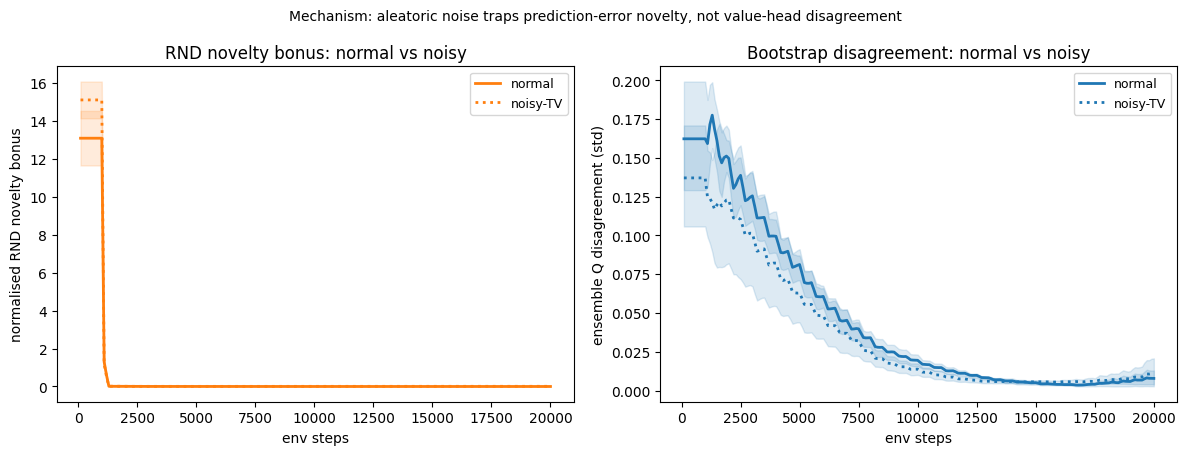

In [13]:
# Mechanism: the exploration-bonus signal of each agent, normal vs noisy.
hw_plots.show_mechanism("results")

## Section G — Analysis questions

Answer each from your own runs' figures and numbers. Each question's point value is
shown next to it.


**Q1 — Normal DeepSea (5 pts).** Using the learning curves, the first-visit-to-goal bars, and the IQM panel, which method finds the treasure sooner and which is more reliable across seeds — and how does the plain Double-DQN baseline compare? Quantify.


RND performed best on normal DeepSea. It started getting reward at about 8k steps and reached around 0.7 return by 20k steps. Double DQN started succeeding later, around 12–13k steps, and Bootstrapped DQN around 15–16k steps. The IQM plot also shows that RND was the most consistent method, while the other two had much lower and more variable final performance.


**Q2 — Noisy TV (5 pts).** How does RND's behaviour change from the normal board to the noisy one? Reference its intrinsic-bonus curve (does it decay?) and its visitation heatmap.


Noisy TV strongly hurt RND. On the normal board, RND reached high return, almost full coverage, and high entropy. On the noisy board, its return stayed near zero, coverage stopped around 0.9, and entropy dropped. The heatmap shows that it spent many visits near the noisy left wall instead of moving toward the treasure. However, the plotted normalized RND bonus does not stay high, so the behavioral failure is clearer than the bonus mechanism in these results.


**Q3 — Mechanism (6 pts).** Why does the noisy TV trap RND but not Bootstrapped DQN? Answer in terms of prediction error vs value-head disagreement (aleatoric vs epistemic uncertainty). What property of the noise is essential?


RND uses prediction error as novelty, so fresh random noise can look like a new state even when it is useless. This is aleatoric uncertainty. Bootstrapped DQN uses disagreement between value heads, which better represents epistemic uncertainty about rewards and actions. Since the noisy features are action-independent and reward-irrelevant, the heads can learn to ignore them, so their disagreement decreases.


**Q4 — Breadth vs depth (5 pts).** From coverage, entropy, and deepest-column-reached, describe each agent's exploration style. Can coverage look healthy while the goal is never reached?


On normal DeepSea, RND had the best combination of broad coverage, high entropy, and repeated goal reaching. Double DQN and Bootstrapped DQN also covered many cells, but reached the treasure less often. On noisy DeepSea, Bootstrapped DQN kept broader and more balanced exploration, while RND concentrated near the noisy wall.

High coverage does not guarantee success because coverage is collected across many episodes, but the goal requires one complete sequence of correct moves in a single episode.


**Q5 — Rigor (5 pts).** Do the IQM CIs / probability-of-improvement support a *significant* difference at 4 seeds? What would strengthen the claim?


The strongest result is RND outperforming Bootstrapped DQN on normal DeepSea: their IQM confidence intervals are clearly separated and the probability of improvement is near 1. Comparisons involving Double DQN are less certain because the intervals are wide. On noisy DeepSea, the intervals overlap, so the ranking is not statistically reliable. More seeds, longer runs, and more DeepSea sizes would make the conclusion stronger.


**Q6 — Practice (4 pts).** For a task with reward-irrelevant sensory noise (e.g. a flickering screen), which method would you choose, and why?


I would choose Bootstrapped DQN for an environment with reward-irrelevant sensory noise. Its exploration is based on value disagreement, so it can learn that random visual features do not affect rewards. RND is more likely to be distracted because unpredictable observations can keep producing prediction error. I would still test both methods with more seeds before making a final choice.


## Section H — Export Experimental Artifacts

This writes **`exploration_artifacts.zip`** (< 10 MB): deterministic fingerprints of your
implementations plus the run records and summaries from the sweep. Submit it with the
notebook.


In [14]:
import hw_grading

out = hw_grading.export_artifacts(
    results_dir="results", out="exploration_artifacts.zip", student_number=STUDENT_NUMBER
)
print("Exported exploration artifacts:", out)

wrote /content/exploration_hw/submission.zip  (1.40 MB)  student_number=401105815
submit this file alongside the notebook: /content/exploration_hw/submission.zip
